Period is 6.289


Text(0, 0.5, 'Theta')

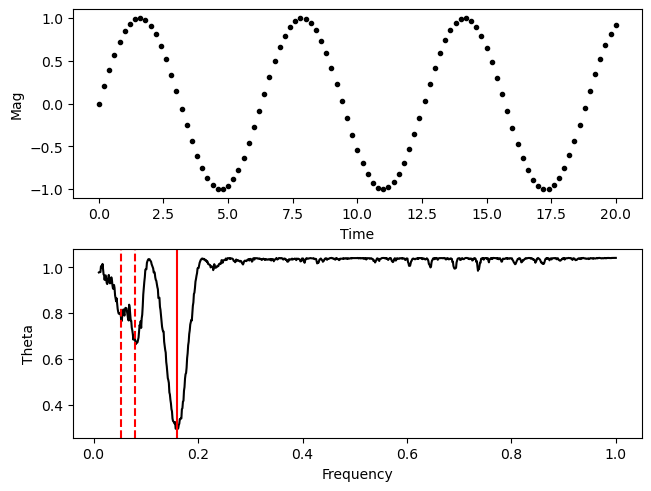

In [11]:
import numpy as np
from pdmpy import pdm
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.timeseries import LombScargle
t = np.linspace(0, 20, 101)
y = np.sin(t)
freq, theta = pdm(t, y, f_min=0.01, f_max=1, delf=1e-3)
print(f'Period is {1 / freq[np.argmin(theta)]:.3f}')
fig, (ax1, ax2) = plt.subplots(2, 1, constrained_layout=True)
ax1.plot(t, y, 'k.')
ax1.set_xlabel('Time')
ax1.set_ylabel('Mag')
ax2.plot(freq, theta, 'k')
ax2.axvline(1/2/np.pi, color='red')
for i in range(2,4):
    ax2.axvline(1/2/i/np.pi, color='red', ls='--')
ax2.set_xlabel('Frequency')
ax2.set_ylabel('Theta')

XTENSION= 'BINTABLE'           / marks the beginning of a new HDU               BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  100 / length of first array dimension                NAXIS2  =                 3853 / length of second array dimension               PCOUNT  =                    0 / group parameter count (not used)               GCOUNT  =                    1 / group count (not used)                         TFIELDS =                   20 / number of table fields                         TTYPE1  = 'TIME    '           / column title: data time stamps                 TFORM1  = 'D       '           / column format: 64-bit floating point           TUNIT1  = 'BJD - 2454833'      / column units: barycenter corrected JD          TDISP1  = 'D14.7   '           / column display format                          TTYPE2  = 'TIMECORR'           / column 

Text(0, 0.5, 'Theta')

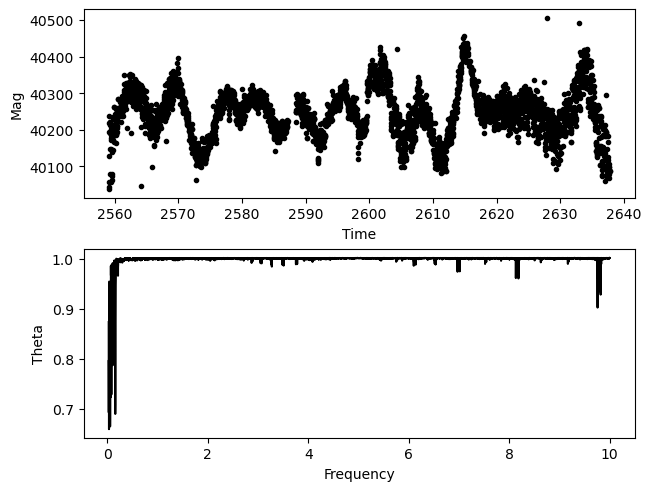

In [41]:
file_path = '/Users/iansterrett/Downloads/mastDownload/K2/ktwo220522664-c08_lc/ktwo220522664-c08_llc.fits'
with fits.open(file_path) as hdul:
    image_data = hdul[1].data
    print(hdul[1].header)
    time_array = image_data['TIME']
    flux_array = image_data['PDCSAP_FLUX']
    mask = np.isfinite(time_array) & np.isfinite(flux_array)
    time_clean = time_array[mask]
    flux_clean = flux_array[mask]

freq, theta = pdm(time_clean, flux_clean, f_min=(1/40), f_max=10, delf=1e-3)
print(f'Period is {1 / freq[np.argmin(theta)]:.3f}')
fig, (ax1, ax2) = plt.subplots(2, 1, constrained_layout=True)
ax1.plot(time_clean, flux_clean, 'k.')
#ax1.set_xlim(2560, 2570)
ax1.set_xlabel('Time')
ax1.set_ylabel('Mag')
ax2.plot(freq, theta, 'k')
ax2.set_xlabel('Frequency')
ax2.set_ylabel('Theta')

Text(0, 0.5, 'Power')

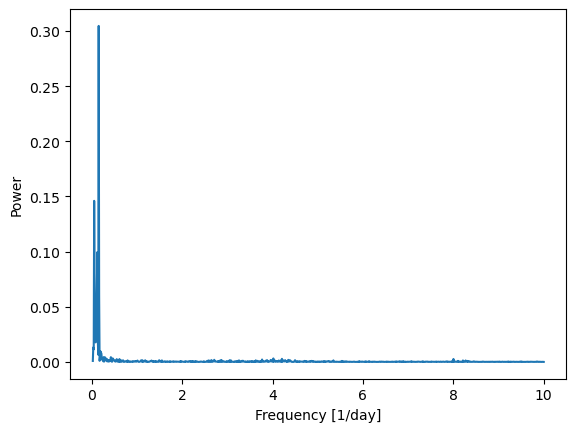

In [35]:
frequencies = np.linspace(1/40, 10.0, 1000)

power = LombScargle(time_clean, flux_clean).power(frequencies)

fig, ax = plt.subplots()
ax.plot(frequencies, power)
ax.set_xlabel("Frequency [1/day]")
ax.set_ylabel("Power")

XTENSION= 'BINTABLE'           /Binary table written by MWRFITS v1.11           BITPIX  =                    8 /Required value                                  NAXIS   =                    2 /Required value                                  NAXIS1  =                   38 /Number of bytes per row                         NAXIS2  =                  319 /Number of rows                                  PCOUNT  =                    0 /Normally 0 (no varying arrays)                  GCOUNT  =                    1 /Required value                                  TFIELDS =                    6 /Number of columns in table                      COMMENT                                                                         COMMENT  *** End of mandatory fields ***                                        COMMENT                                                                         WCSN4P  = 'PHYSICAL'           / table column WCS name                          WCAX4P  =                    2 / table c

Text(0, 0.5, 'Theta')

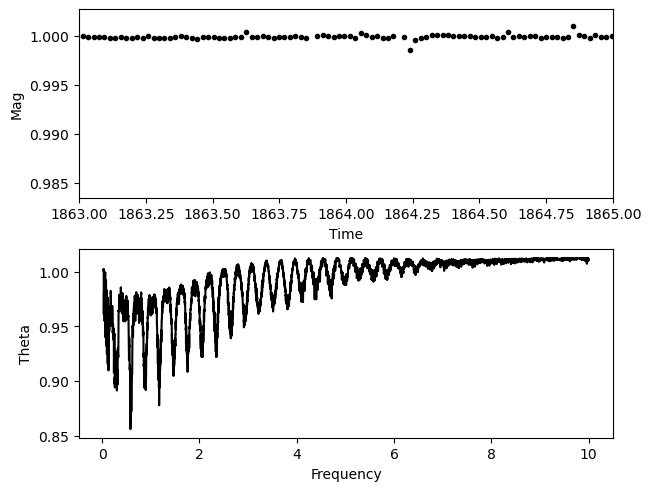

In [49]:
file_name = '/Users/iansterrett/Downloads/mastDownload/HLSP/hlsp_k2sff_k2_lightcurve_060017806-cet_kepler_v1_llc.fits'
with fits.open(file_name) as hdul:
    image_data = hdul[1].data
    print(hdul[1].header)
    time_array = image_data['T']
    flux_array = image_data['FCOR']
    mask = np.isfinite(time_array) & np.isfinite(flux_array)
    time_clean = time_array[mask]
    flux_clean = flux_array[mask]

freq, theta = pdm(time_clean, flux_clean, f_min=(1/40), f_max=10, delf=1e-3)
print(f'Period is {1 / freq[np.argmin(theta)]:.3f}')
fig, (ax1, ax2) = plt.subplots(2, 1, constrained_layout=True)
ax1.plot(time_clean, flux_clean, 'k.')
ax1.set_xlim(1863, 1865)
ax1.set_xlabel('Time')
ax1.set_ylabel('Mag')
ax2.plot(freq, theta, 'k')
ax2.set_xlabel('Frequency')
ax2.set_ylabel('Theta')

Text(0, 0.5, 'Power')

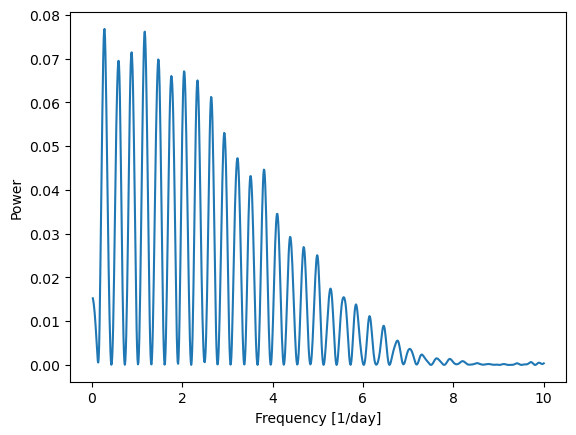

In [47]:
frequencies = np.linspace(1/40, 10.0, 1000)

power = LombScargle(time_clean, flux_clean).power(frequencies)

fig, ax = plt.subplots()
ax.plot(frequencies, power)
ax.set_xlabel("Frequency [1/day]")
ax.set_ylabel("Power")

In [75]:
import pandas as pd
import numpy as np

data = pd.read_csv(
    txt_file,
    sep=r"\s+",
    comment="#",
    skiprows=1,
    names=["time_raw", "flux_raw"],
    usecols=[0, 1],
    engine="python"
)

# strip commas and convert to float
time = pd.to_numeric(data["time_raw"].astype(str).str.replace(",", "", regex=False), errors="coerce").to_numpy()
flux = pd.to_numeric(data["flux_raw"].astype(str).str.replace(",", "", regex=False), errors="coerce").to_numpy()

# drop any bad rows (NaNs) just in case
m = np.isfinite(time) & np.isfinite(flux)
time = time[m]
flux = flux[m]

print(time[:5], flux[:5])

[2307.55026814 2307.57070014 2307.59113225 2307.61156415 2307.63199615] [0.95753093 0.9589452  0.96037521 0.96185494 0.96354087]


Period is 4.167


Text(0, 0.5, 'Theta')

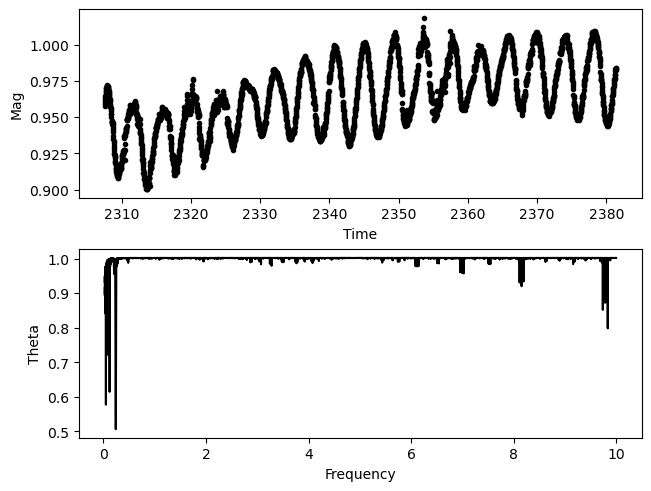

In [77]:
freq, theta = pdm(time, flux, f_min=(1/40), f_max=10, delf=1e-3)
print(f'Period is {1 / freq[np.argmin(theta)]:.3f}')
fig, (ax1, ax2) = plt.subplots(2, 1, constrained_layout=True)
ax1.plot(time, flux, 'k.')
ax1.set_xlabel('Time')
ax1.set_ylabel('Mag')
ax2.plot(freq, theta, 'k')
ax2.set_xlabel('Frequency')
ax2.set_ylabel('Theta')

Text(0, 0.5, 'Power')

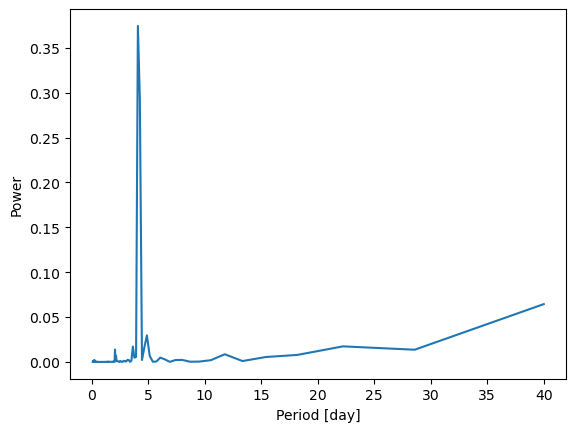

In [80]:
frequencies = np.linspace(1/40, 10.0, 1000)

power = LombScargle(time, flux).power(frequencies)

fig, ax = plt.subplots()
ax.plot(1/frequencies, power)
ax.set_xlabel("Period [day]")
ax.set_ylabel("Power")

Period is 4.167


Text(0, 0.5, 'Theta')

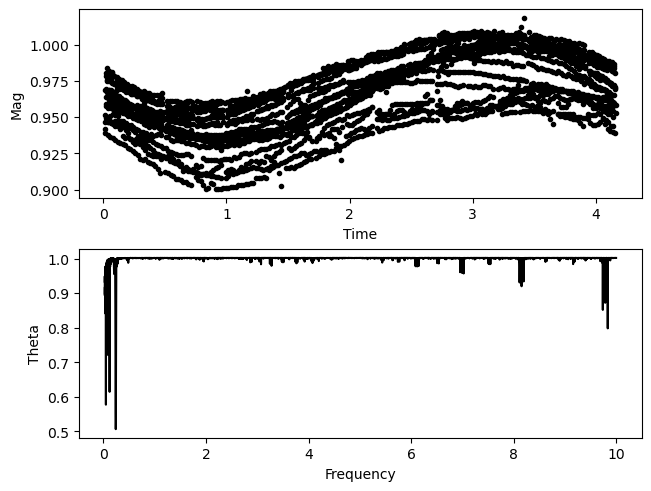

In [86]:
mod_time = time%4.167
freq, theta = pdm(time, flux, f_min=(1/40), f_max=10, delf=1e-3)
print(f'Period is {1 / freq[np.argmin(theta)]:.3f}')
fig, (ax1, ax2) = plt.subplots(2, 1, constrained_layout=True)
ax1.plot(mod_time, flux, 'k.')
ax1.set_xlabel('Time')
ax1.set_ylabel('Mag')
ax2.plot(freq, theta, 'k')
ax2.set_xlabel('Frequency')
ax2.set_ylabel('Theta')